In [46]:
import plumed
import matplotlib.pyplot as plt
import numpy as np
import subprocess
import os


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_126855/198154149.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  seed_colvar=plumed.read_as_pandas(infile)
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_126855/198154149.py:61: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  colvar=plumed.read_as_pandas(infile)
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/jonathan/anaconda3/envs/plumed1/lib/libplumedKernel.so" +++
/tmp/ipykernel_126855/198154149.py:61: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` in

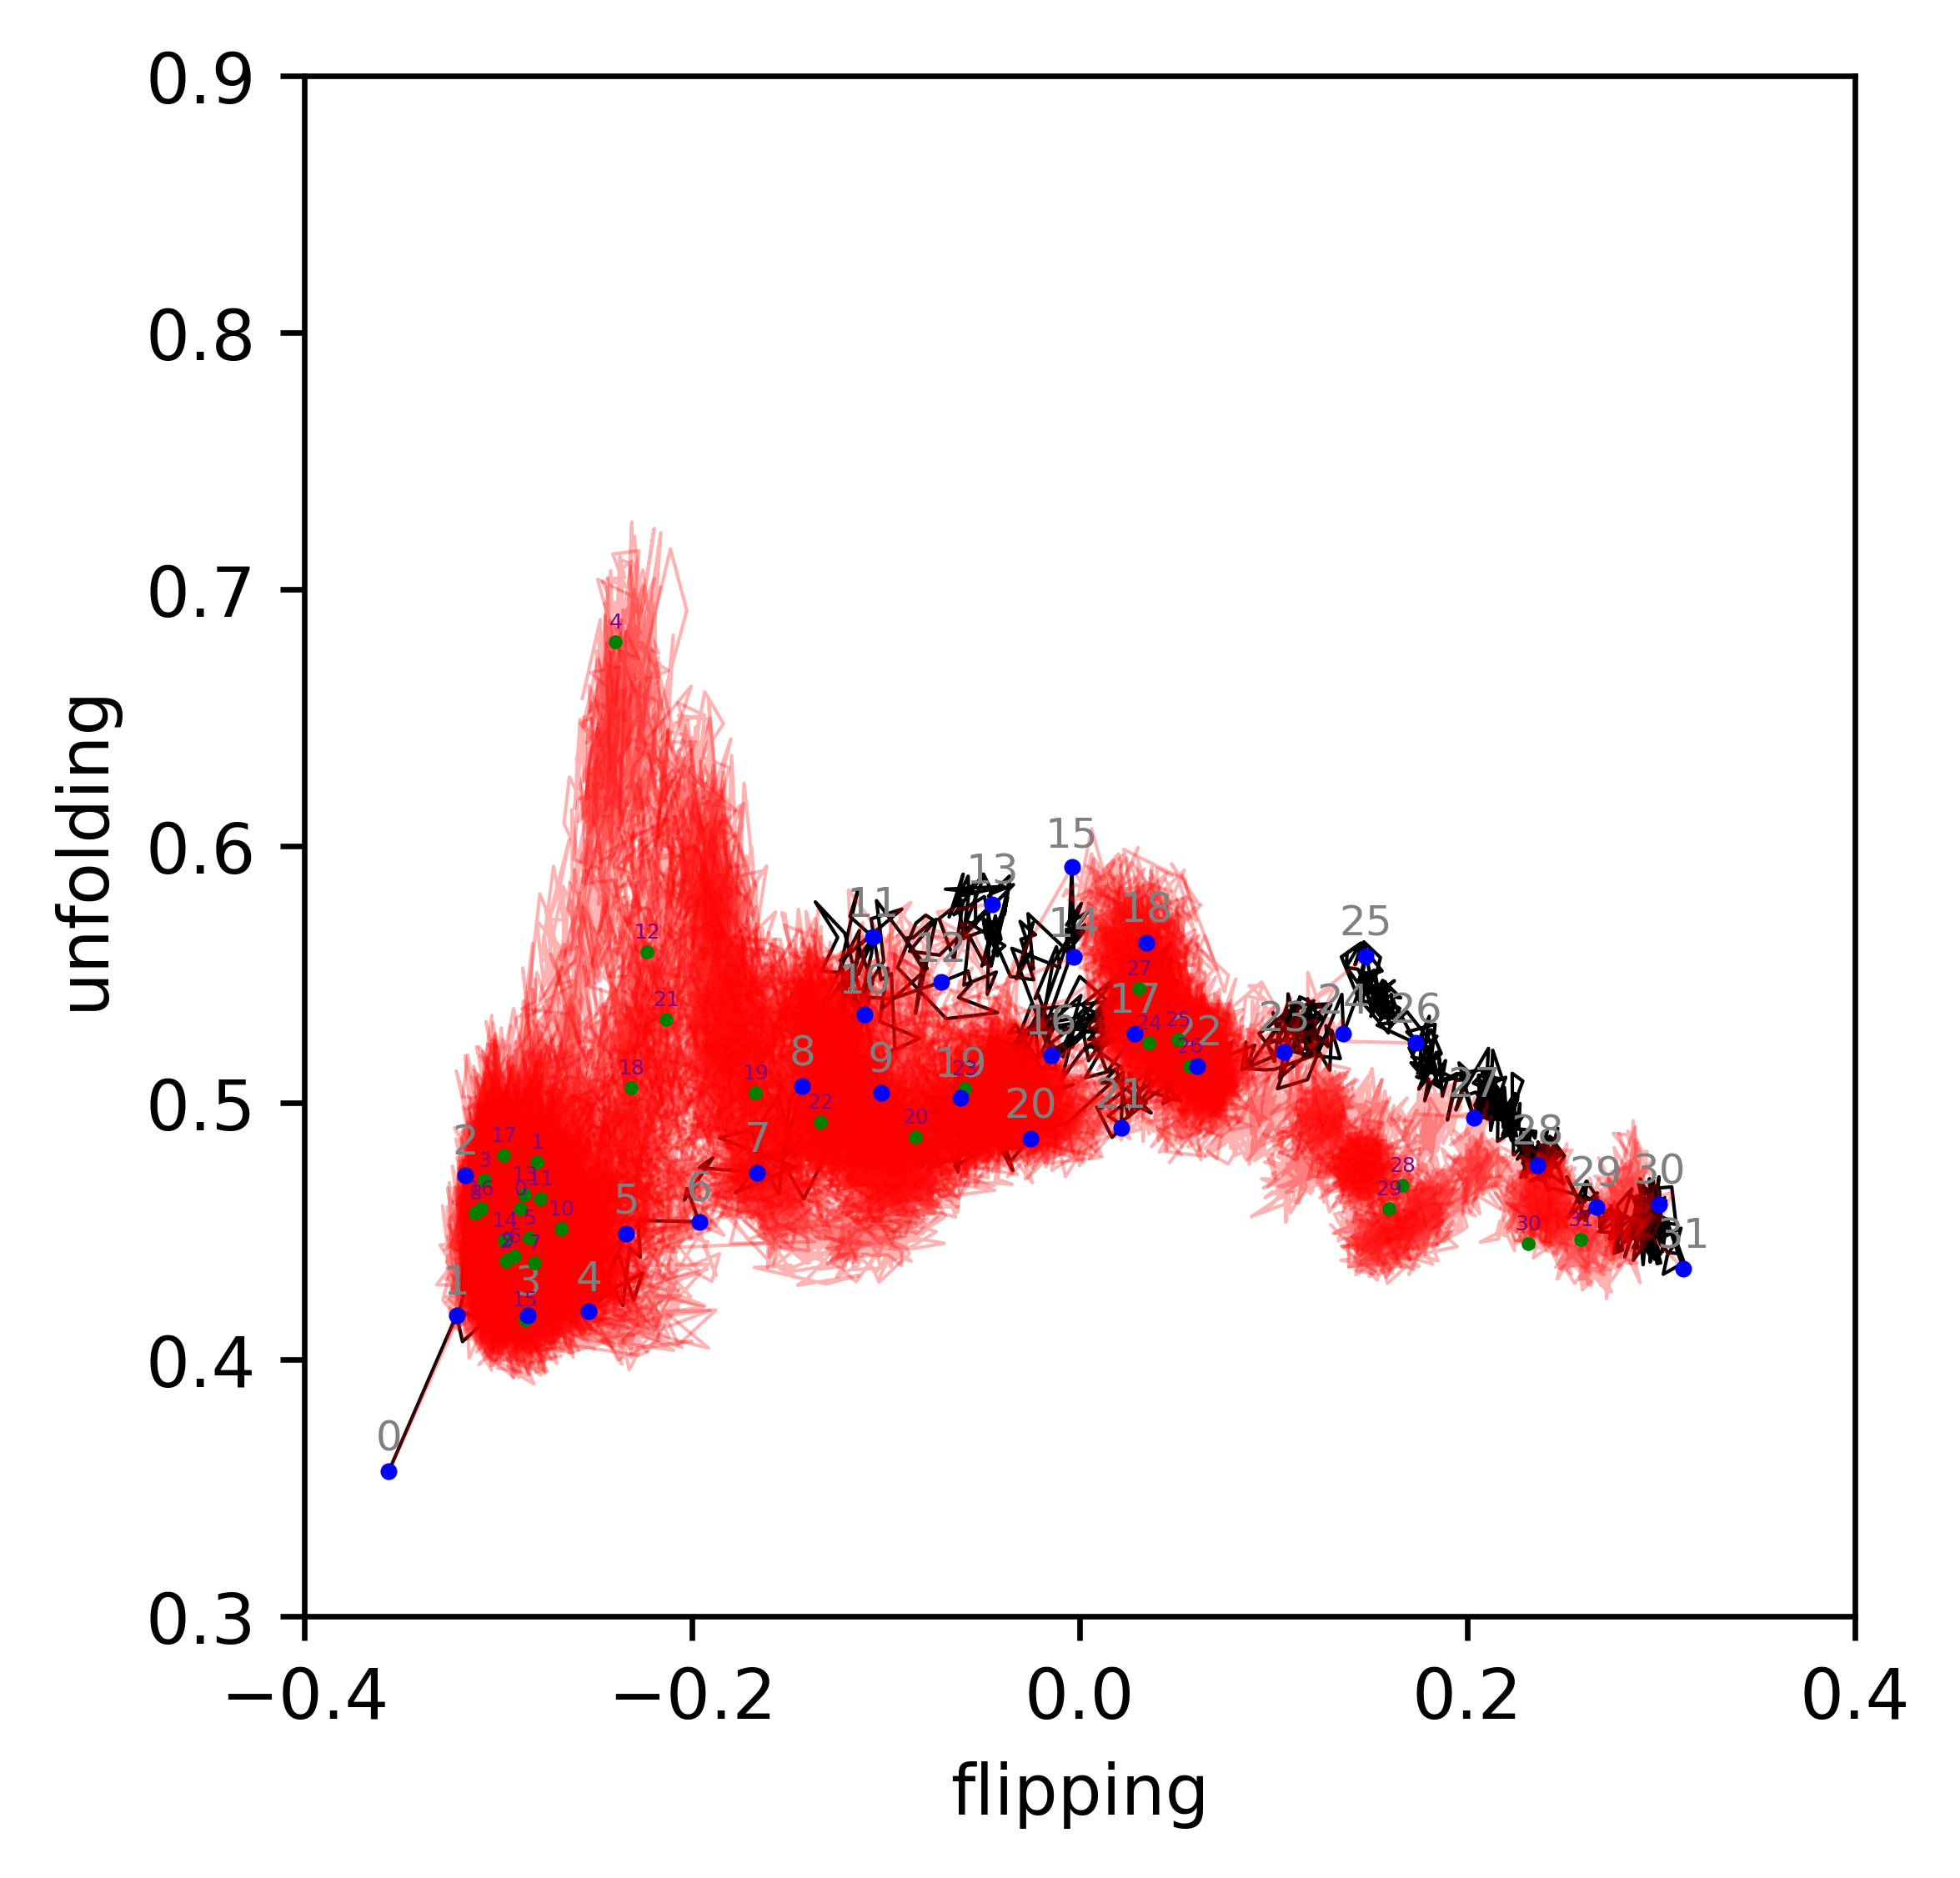

In [48]:
#run used to seed trajectories

seed_run = 4
seed_init_state = "c"
seed_walker = 1

infile = f"/home/jonathan/Documents/grabelab/aac1-nt-transport/metadynamics/run{seed_run}/run_{seed_init_state}/COLVAR.{seed_walker}"
seed_colvar=plumed.read_as_pandas(infile)

plt.figure(figsize=(4,4),dpi=600)

freq = 1

delta = list(seed_colvar.pc_f1b[::freq])
pc_c = list(seed_colvar.pc_fc[::freq])
pc_m = list(seed_colvar.pc_fm[::freq])

sigma = [i+j for i,j in zip(pc_c,pc_m)]

plt.plot(delta, sigma, color = "black", linewidth=0.5)

#get regularly spaced points that are at least 0.03 nm apart in both dimensions
time = list(seed_colvar.time[::freq]*0.001*freq)

coords = []
times = []

thresh = 0.03

for t, (d,s) in enumerate(zip(delta, sigma)):
    farenough = True
    for c in coords:
        if abs(d - c[0]) < thresh and abs(s - c[1]) < thresh:
            farenough = False
            break

    if farenough or t == len(time)-1:
        times.append(time[t])
        #print(f"{time[t]} ns")
        coords.append((d,s))
        plt.annotate(f"{len(coords)-1}", (d, s), textcoords="offset points", xytext=(0,3), ha='center', color="grey", fontsize=6)
        

#print(f"found {len(coords)} points")
plt.scatter([c[0] for c in coords], [c[1] for c in coords], color = "blue", s=2, zorder = 10000)

test_ind = -1
nparallel = 32
for wi in range(nparallel):
    if wi != test_ind and test_ind >=0:
        continue

    lastdelta = 0
    lastsigma = 0

    for parti in range(100):

        infile = f"/home/jonathan/Documents/grabelab/aac1-nt-transport/relaxation/run1/run_c/{wi}/COLVAR.{parti:04d}"
        if os.path.exists(infile):

            colvar=plumed.read_as_pandas(infile)

            freq = 1

            delta = list(colvar.pc_f1b[::freq])
            pc_c = list(colvar.pc_fc[::freq])
            pc_m = list(colvar.pc_fm[::freq])

            sigma = [i+j for i,j in zip(pc_c,pc_m)]

            plt.plot(delta, sigma, color = "red", linewidth=0.5, alpha=0.3)

            lastdelta = delta[-1]
            lastsigma = sigma[-1]

    plt.scatter(lastdelta, lastsigma, color = "green", s=1, zorder=999)
    plt.annotate(f"{wi}", (lastdelta, lastsigma), textcoords="offset points", xytext=(0,2), ha='center', color="purple", fontsize=3, zorder=999999)


plt.xlabel("flipping")
plt.ylabel("unfolding")

plt.xlim(-0.4, 0.4)
plt.ylim(0.3, 0.9)
plt.show()

In [ ]:
#run used to seed trajectories

seed_run = 4
seed_init_state = "c"
seed_walker = 1

infile = f"/home/jonathan/Documents/grabelab/aac1-nt-transport/metadynamics/run{seed_run}/run_{seed_init_state}/COLVAR.{seed_walker}"
seed_colvar=plumed.read_as_pandas(infile)

plt.figure(figsize=(4,4),dpi=600)

freq = 1

delta = list(seed_colvar.pc_f1b[::freq])
pc_c = list(seed_colvar.pc_fc[::freq])
pc_m = list(seed_colvar.pc_fm[::freq])

sigma = [i+j for i,j in zip(pc_c,pc_m)]

plt.plot(delta, sigma, color = "black", linewidth=0.5)

#get regularly spaced points that are at least 0.03 nm apart in both dimensions
time = list(seed_colvar.time[::freq]*0.001*freq)

coords = []
times = []

windowwidth = 0.02

# thresh = 0.03
for win_x in range(100):

    for t, (d,s) in enumerate(zip(delta, sigma)):
        farenough = True
        for c in coords:
            if abs(d - c[0]) < thresh and abs(s - c[1]) < thresh:
                farenough = False
                break

        if farenough or t == len(time)-1:
            times.append(time[t])
            #print(f"{time[t]} ns")
            coords.append((d,s))
            plt.annotate(f"{len(coords)-1}", (d, s), textcoords="offset points", xytext=(0,3), ha='center', color="grey", fontsize=6)
            

#print(f"found {len(coords)} points")
plt.scatter([c[0] for c in coords], [c[1] for c in coords], color = "blue", s=2, zorder = 10000)

In [ ]:
#######################################################################################################
#                                            Trimmings
#######################################################################################################

In [ ]:

#plt.scatter(delta[-1], sigma[-1], color = "black", s=2)
#plt.annotate(f"{init_state}{walker}", (delta[-1], sigma[-1]), textcoords="offset points", xytext=(0,5), ha='center', fontsize=6)

# #mark regular time intervals along trajectory
# window_freq = len(list(seed_colvar.pc_f1b))//32
# print(window_freq)

# wdelta = list(seed_colvar.pc_f1b[::window_freq])
# wpc_c = list(seed_colvar.pc_fc[::window_freq])
# wpc_m = list(seed_colvar.pc_fm[::window_freq])

# wsigma = [i+j for i,j in zip(wpc_c,wpc_m)]

# print(f"{len(wdelta)} windows")

# plt.scatter(wdelta, wsigma, color = "red", s=2)

# test_state = "c"
# test_walker = 1
run_num = 1
init_state = "c"

# nwalkers = 8
# for init_state in ["c","m"]:
#     for walker in range(nwalkers):
        if init_state == "c":
        else:
            infile = f"/home/jonathan/Documents/grabelab/aac1-nt-transport/metadynamics/run{run_num}/run_{init_state}/COLVAR.{walker}"

        seed_colvar=plumed.read_as_pandas(infile)

        freq = 1

        delta = list(seed_colvar.pc_f1b[::freq])
        pc_c = list(seed_colvar.pc_fc[::freq])
        pc_m = list(seed_colvar.pc_fm[::freq])

        sigma = [i+j for i,j in zip(pc_c,pc_m)]

        if init_state == test_state and walker == test_walker:
            color = (0,0,0)
        elif init_state == "c":
            color = (0,walker/nwalkers,1)
            continue
        elif init_state == "m":
            color = (1,walker/nwalkers,0)
            continue

        plt.plot(delta, sigma, color = color, linewidth=0.5)

        plt.scatter(delta[-1], sigma[-1], color = color, s=2)
        plt.annotate(f"{init_state}{walker}", (delta[-1], sigma[-1]), textcoords="offset points", xytext=(0,5), ha='center', fontsize=6)


        #mark regular intervals along trajectory
        window_freq = len(list(seed_colvar.pc_f1b))//32
        print(window_freq)

        wdelta = list(seed_colvar.pc_f1b[::window_freq])
        wpc_c = list(seed_colvar.pc_fc[::window_freq])
        wpc_m = list(seed_colvar.pc_fm[::window_freq])

        wsigma = [i+j for i,j in zip(wpc_c,wpc_m)]

        print(f"{len(wdelta)} windows")

        plt.scatter(wdelta, wsigma, color = "red", s=2)

        coords = []

        for d,s in zip(delta, sigma):
            farenough = True
            for c in coords:
                if abs(d - c[0]) < 0.03 and abs(s - c[1]) < 0.03:
                    farenough = False
                    break

            if farenough:
                coords.append((d,s))

        print(len(coords))
        plt.scatter([c[0] for c in coords], [c[1] for c in coords], color = "blue", s=2)